In [1]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt

In [2]:
sample = [ np.random.randint(0, 10) for _ in range (30) ]
print(f"Sample: {sample}")
print(f"Mean: {np.mean(sample)}")
print(f"Variance: {np.var(sample)}")

Sample: [8, 0, 8, 3, 3, 4, 5, 1, 7, 6, 2, 1, 6, 7, 8, 7, 9, 9, 2, 4, 7, 6, 3, 2, 7, 8, 9, 7, 7, 2]
Mean: 5.266666666666667
Variance: 7.328888888888886


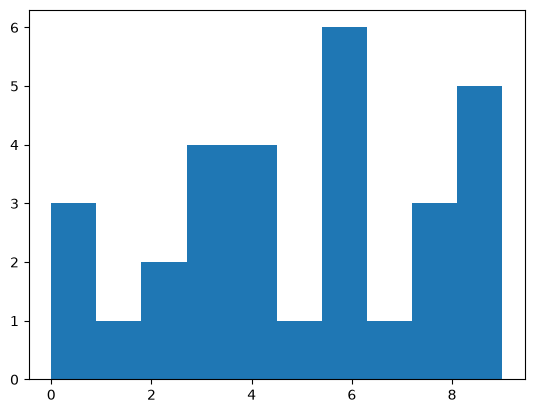

In [37]:
plt.hist(sample)
plt.show()

In [2]:
df = pd.read_csv("../../data/SOCR_MLB.tsv", sep = '\t', header = None, names = ['Name', 'Team', 'Role', 'Weight', 'Height', 'Age'])
df

,Name,Team,Role,Weight,Height,Age
0,Adam_Donachie,BAL,Catcher,74,180.0,22.99
1,Paul_Bako,BAL,Catcher,74,215.0,34.69
2,Ramon_Hernandez,BAL,Catcher,72,210.0,30.78
3,Kevin_Millar,BAL,First_Baseman,72,210.0,35.43
4,Chris_Gomez,BAL,First_Baseman,73,188.0,35.71
...,...,...,...,...,...,...
1029,Brad_Thompson,STL,Relief_Pitcher,73,190.0,25.08
1030,Tyler_Johnson,STL,Relief_Pitcher,74,180.0,25.73
1031,Chris_Narveson,STL,Relief_Pitcher,75,205.0,25.19
1032,Randy_Keisler,STL,Relief_Pitcher,75,190.0,31.01


In [40]:
df[['Age', 'Height', 'Weight']].mean()

Age        28.736712
Height    201.689255
Weight     73.697292
dtype: float64

In [41]:
print(list(df['Height'])[:20])

[180.0, 215.0, 210.0, 210.0, 188.0, 176.0, 209.0, 200.0, 231.0, 180.0, 188.0, 180.0, 185.0, 160.0, 180.0, 185.0, 197.0, 189.0, 185.0, 219.0]


In [3]:
mean = df['Height'].mean()
variance = df['Height'].var()
std = df['Height'].std()
print(f"Mean: {mean}\nVariance: {variance}\nStandard deviation: {std}")

Mean: 201.6892545982575
Variance: 440.64268481205494
Standard deviation: 20.99149077154967


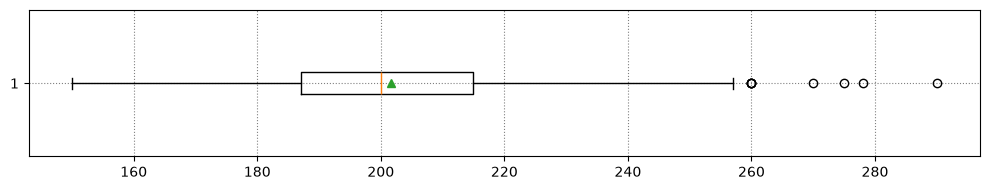

In [12]:
plt.figure(figsize=(10,2))
plt.boxplot(df['Height'].ffill(), orientation='horizontal', showmeans=True)
plt.grid(color='gray', linestyle='dotted')
plt.tight_layout()
plt.show()

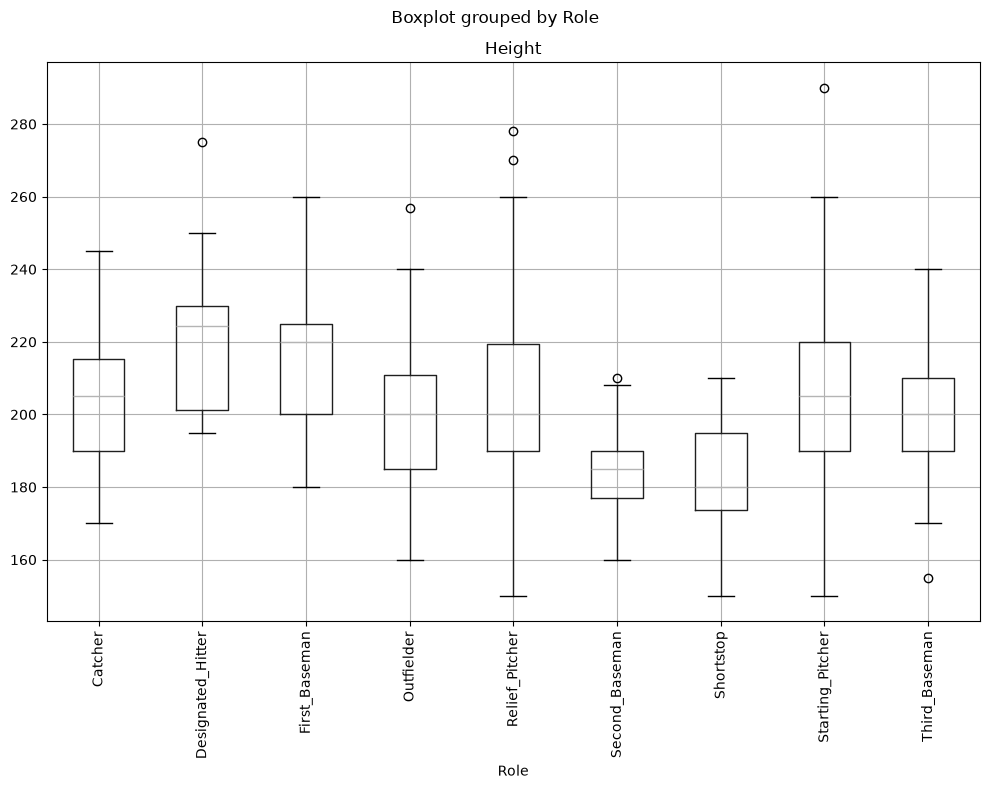

In [13]:
df.boxplot(column='Height', by='Role', figsize=(10,8))
plt.xticks(rotation='vertical')
plt.tight_layout()
plt.show()

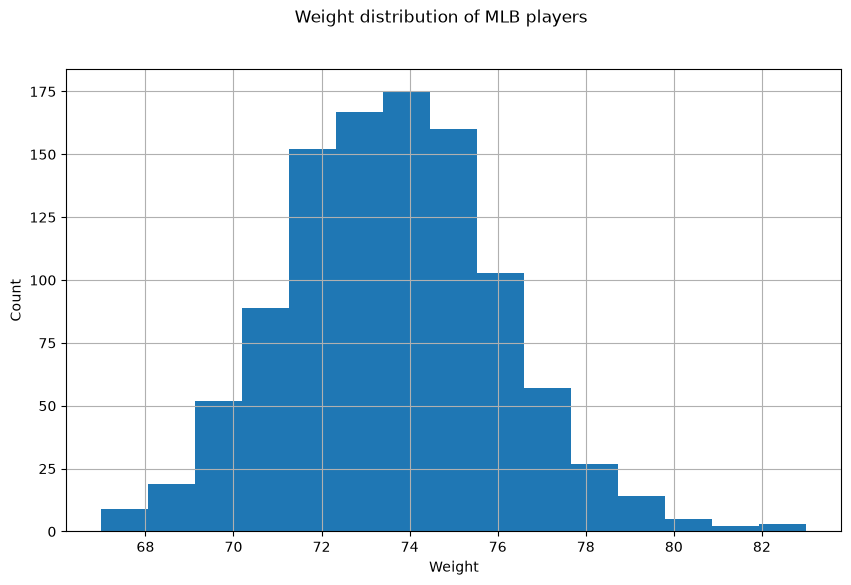

In [14]:
df['Weight'].hist(bins=15, figsize=(10,6))
plt.suptitle('Weight distribution of MLB players')
plt.xlabel('Weight')
plt.ylabel('Count')
plt.show()

In [15]:
generated = np.random.normal(mean, std, 1000)
generated[:20]

array([239.97610652, 209.17974973, 227.30967801, 208.67035819,
       159.32392122, 233.11840329, 184.10172255, 184.07246713,
       204.84870238, 209.97486684, 177.15226045, 153.81726813,
       181.28637256, 210.03823045, 254.71163567, 201.27587416,
       231.12449606, 185.28146333, 223.05893107, 190.28466081])

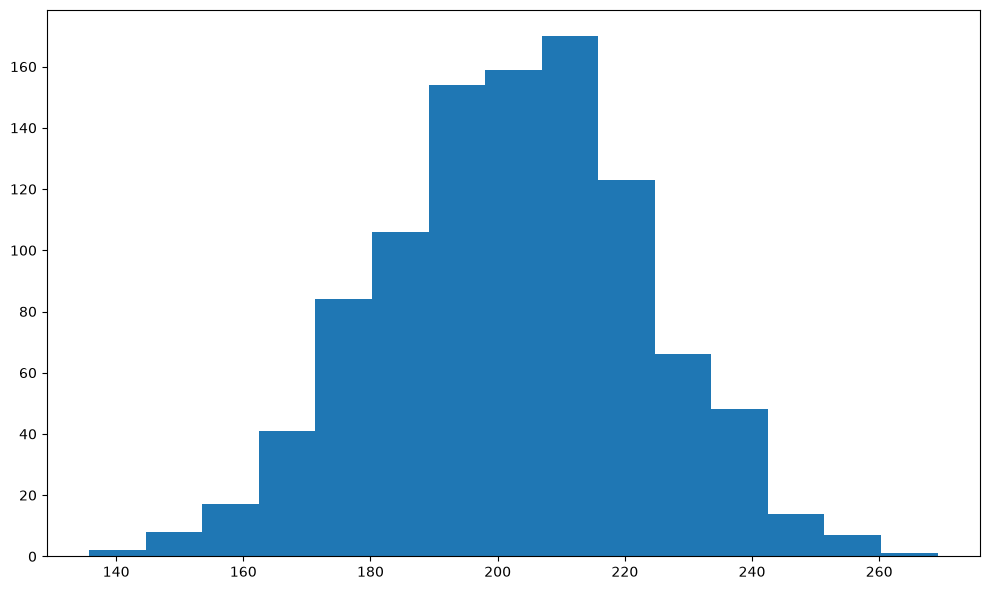

In [16]:
plt.figure(figsize=(10,6))
plt.hist(generated, bins=15)
plt.tight_layout()
plt.show()

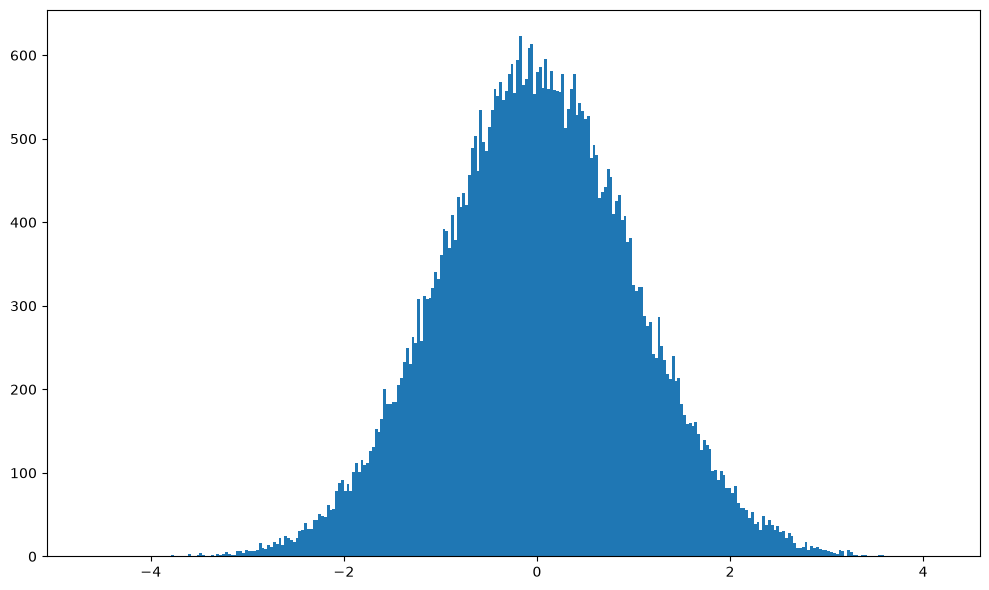

In [17]:
plt.figure(figsize=(10,6))
plt.hist(np.random.normal(0, 1, 50000), bins=300)
plt.tight_layout()
plt.show()

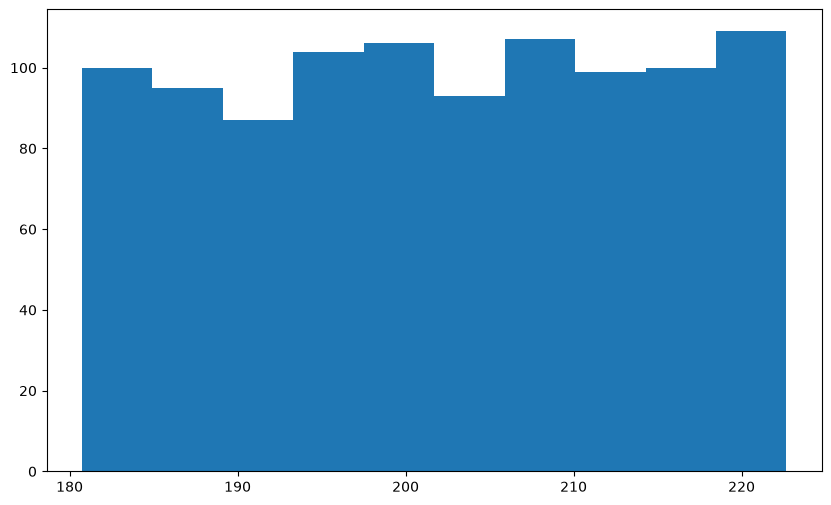

In [7]:
wrong_sample = np.random.rand(1000)*2*std+mean-std
plt.figure(figsize=(10,6))
plt.hist(wrong_sample)
#plt.tight_layout()
plt.show()

In [4]:
import scipy.stats

In [5]:
def mean_confidence_interval(data, confidence=0.95):
    a = 1.0 * np.array(data)
    n = len(a)
    m, se = np.mean(a), scipy.stats.sem(a)
    h = se * scipy.stats.t.ppf((1 + confidence) / 2., n-1)
    return m, h

for p in [0.85, 0.9, 0.95]:
    m, h = mean_confidence_interval(df['Weight'].ffill(),p)
    print(f"p = {p:.2f}, mean = {m:.2f} ± {h:.2f}")

p = 0.85, mean = 73.70 ± 0.10
p = 0.90, mean = 73.70 ± 0.12
p = 0.95, mean = 73.70 ± 0.14


In [7]:
help(df['Weight'].fillna)

Help on method fillna in module pandas.core.generic:

fillna(
    value: 'Hashable | Mapping | Series | DataFrame',
    *,
    axis: 'Axis | None' = None,
    inplace: 'bool' = False,
    limit: 'int | None' = None
) -> 'Self' method of pandas.Series instance
    Fill NA/NaN values with `value`.

    Parameters
    ----------
    value : scalar, dict, Series, or DataFrame
        Value to use to fill holes (e.g. 0), alternately a
        dict/Series/DataFrame of values specifying which value to use for
        each index (for a Series) or column (for a DataFrame).  Values not
        in the dict/Series/DataFrame will not be filled. This value cannot
        be a list.
    axis : {0 or 'index'} for Series, {0 or 'index', 1 or 'columns'} for DataFrame
        Axis along which to fill missing values. For `Series`
        this parameter is unused and defaults to 0.
    inplace : bool, default False
        If True, fill in-place. Note: this will modify any
        other views on this objec

In [8]:
df['Weight'].fillna?

Object `fillna` not found.


In [10]:
help(scipy.stats.t.ppf)

Help on method ppf in module scipy.stats._distn_infrastructure:

ppf(q, *args, **kwds) method of scipy.stats._continuous_distns.t_gen instance
    Percent point function (inverse of `cdf`) at q of the given RV.

    Parameters
    ----------
    q : array_like
        lower tail probability
    arg1, arg2, arg3,... : array_like
        The shape parameter(s) for the distribution (see docstring of the
        instance object for more information)
    loc : array_like, optional
        location parameter (default=0)
    scale : array_like, optional
        scale parameter (default=1)

    Returns
    -------
    x : array_like
        quantile corresponding to the lower tail probability q.



In [11]:
scipy.stats.t.ppf?

Signature: scipy.stats.t.ppf(q, *args, **kwds)
Docstring:
Percent point function (inverse of `cdf`) at q of the given RV.

Parameters
----------
q : array_like
    lower tail probability
arg1, arg2, arg3,... : array_like
    The shape parameter(s) for the distribution (see docstring of the
    instance object for more information)
loc : array_like, optional
    location parameter (default=0)
scale : array_like, optional
    scale parameter (default=1)

Returns
-------
x : array_like
    quantile corresponding to the lower tail probability q.
File:      c:\users\utkar\jupyternotebooks\venv\lib\site-packages\scipy\stats\_distn_infrastructure.py
Type:      method

In [21]:
df.groupby('Role').agg({'Weight': 'mean', 'Height': 'mean', 'Age': 'count'}).rename(columns = {'Age': 'Count'})

,Weight,Height,Count
Role,,,
Catcher,72.723684,204.328947,76
Designated_Hitter,74.222222,220.888889,18
First_Baseman,74.000000,213.109091,55
Outfielder,73.010309,199.113402,194
Relief_Pitcher,74.374603,203.517460,315
Second_Baseman,71.362069,184.344828,58
Shortstop,71.903846,182.923077,52
Starting_Pitcher,74.719457,205.163636,221
Third_Baseman,73.044444,200.955556,45


In [11]:
for p in [0.85, 0.9, 0.9999]:
    m1, h1 = mean_confidence_interval(df.loc[df['Role'] == 'First_Baseman', ['Height']], p)
    m2, h2 = mean_confidence_interval(df.loc[df['Role'] == 'Second_Baseman', ['Height']], p)
    print(f'Confidence = {p:.2f}, 1st basemen height: {m1-h1[0]:.2f}..{m1+h1[0]:.2f}, 2nd basemen height: {m2-h2[0]:.2f}..{m2+h2[0]:.2f}')

Confidence = 0.85, 1st basemen height: 209.36..216.86, 2nd basemen height: 182.24..186.45
Confidence = 0.90, 1st basemen height: 208.82..217.40, 2nd basemen height: 181.93..186.76
Confidence = 1.00, 1st basemen height: 202.33..223.89, 2nd basemen height: 178.30..190.39


In [12]:
from scipy.stats import ttest_ind

In [13]:
tval, pval = ttest_ind(df.loc[df['Role'] == 'First_Baseman', ['Height']], df.loc[df['Role'] == 'Second_Baseman', ['Height']], equal_var=False)
print(f"T-value: {tval[0]:.2f}, P-value: {pval[0]:.2f}")

T-value: 9.77, P-value: 0.00


In [6]:
def normal_random(sample_size=100):
    sample = [random.uniform(0, 1) for _ in range(sample_size)]
    return sum(sample) / sample_size

In [7]:
sample = [normal_random() for _ in range(100)]

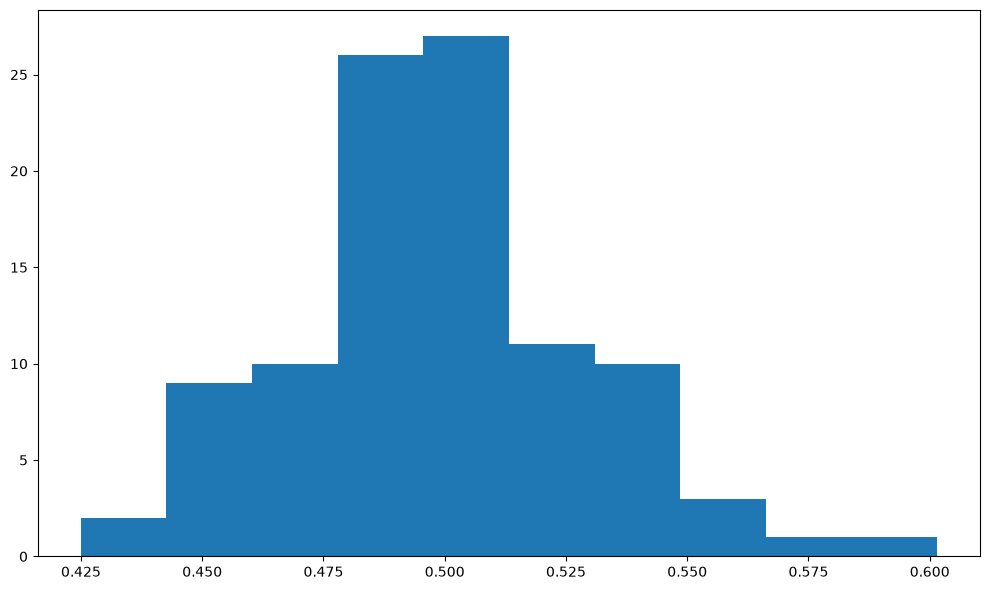

In [8]:
plt.figure(figsize=(10,6))
plt.hist(sample)
plt.tight_layout()
plt.show()

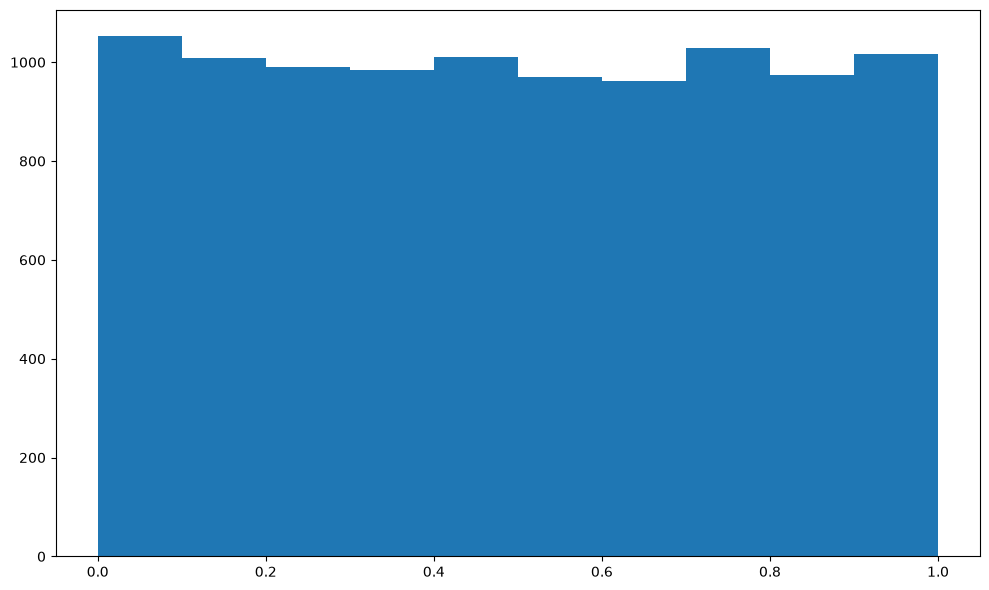

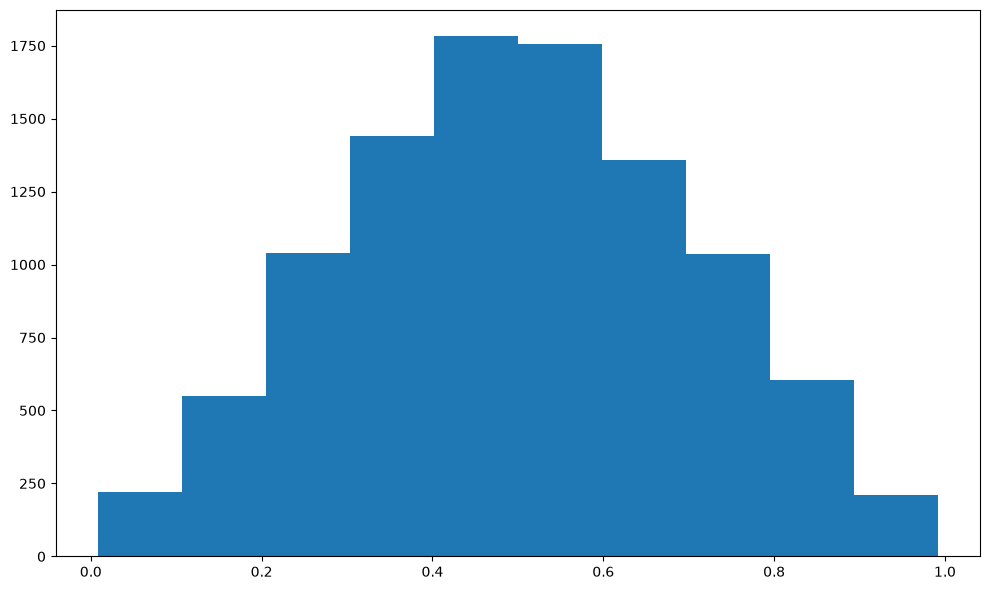

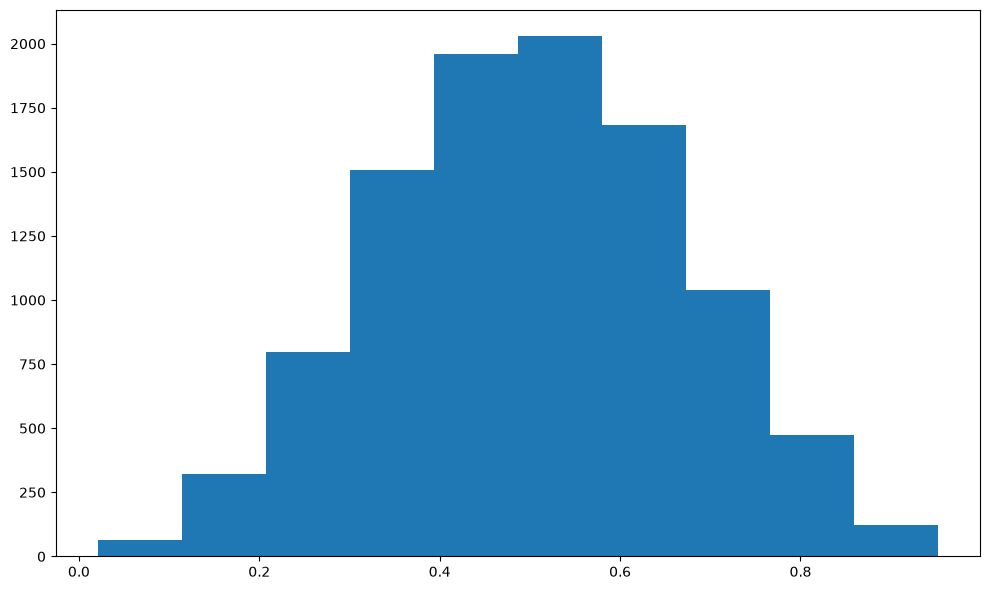

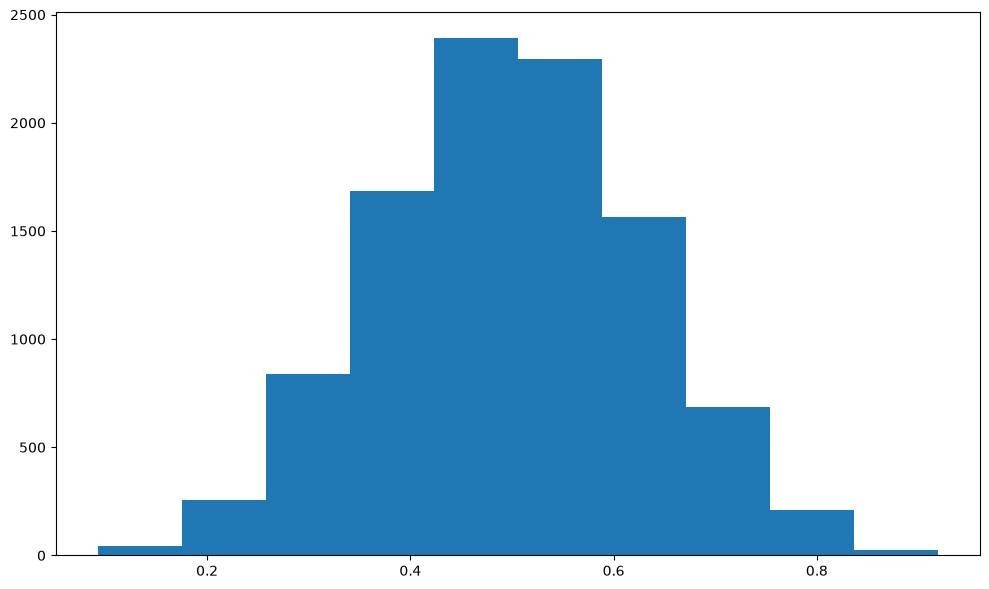

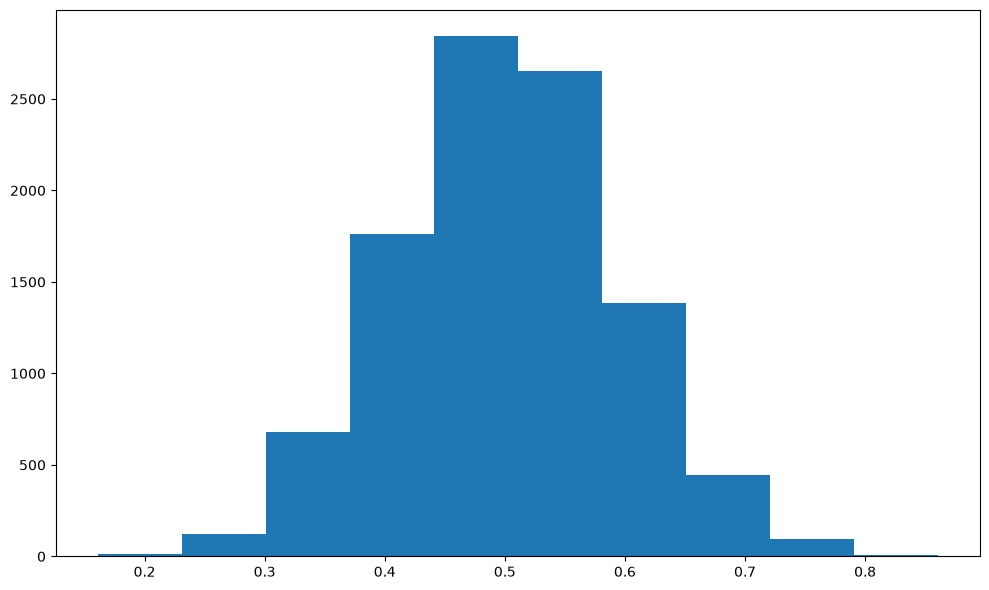

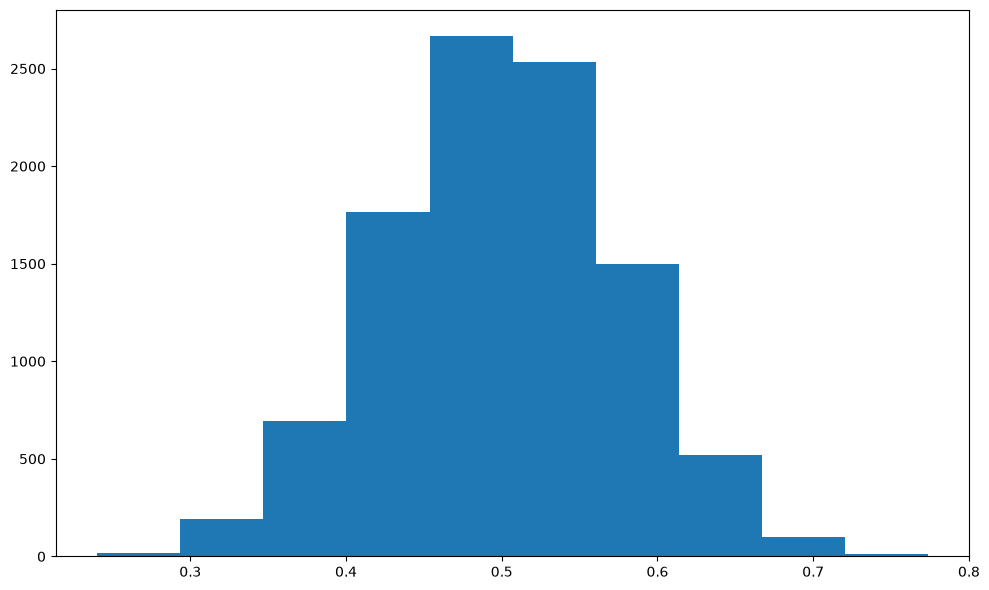

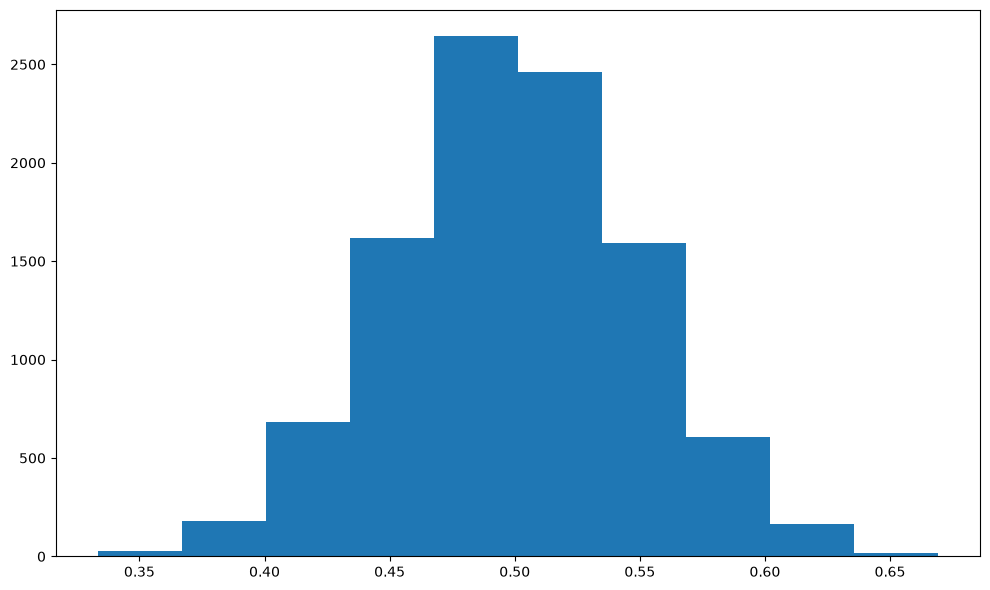

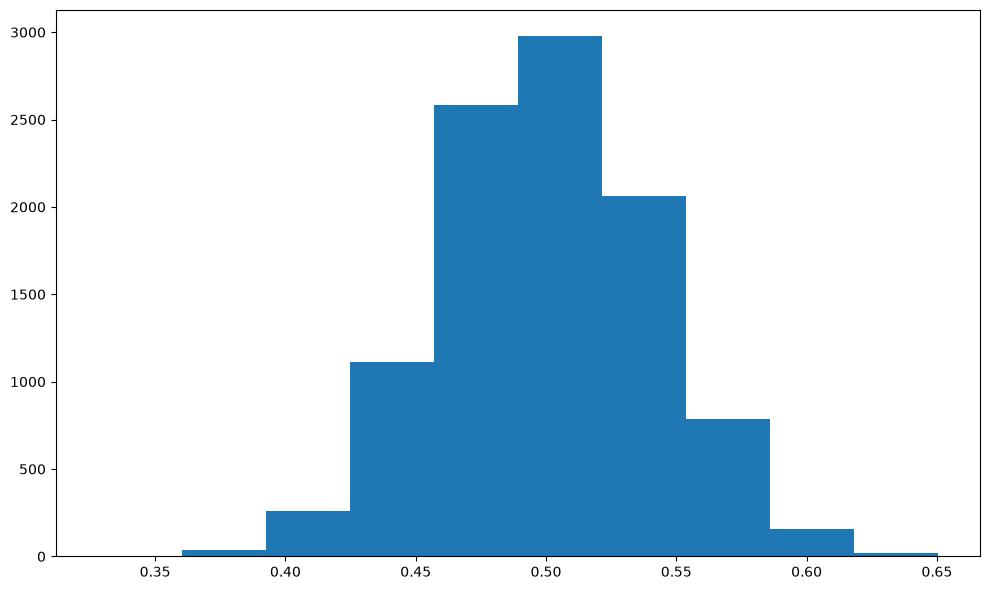

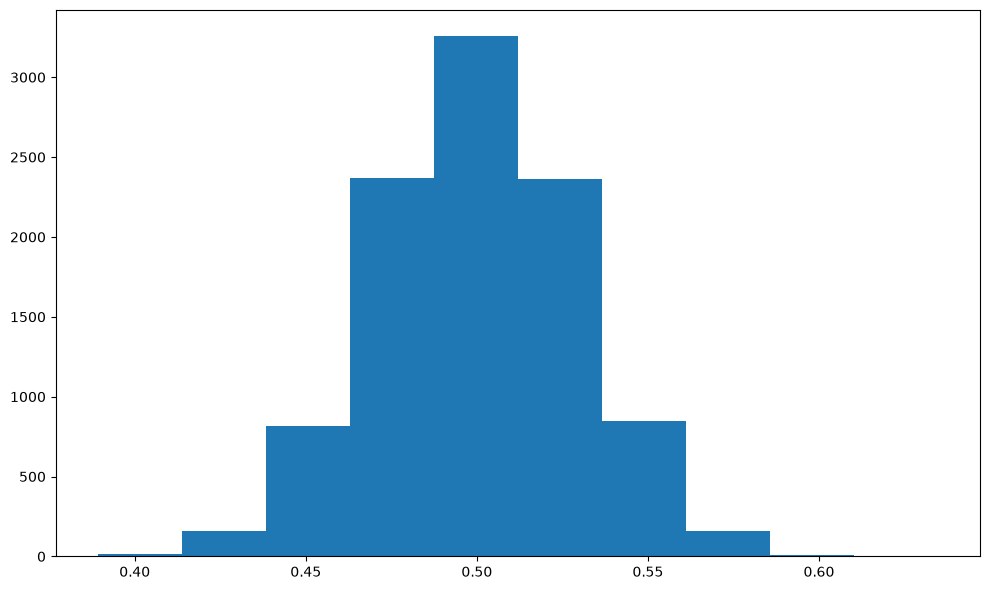

In [10]:
for size in [1, 2, 3, 5, 10, 15, 35, 50, 100]:
    sample = [normal_random(size) for _ in range(10000)]
    plt.figure(figsize=(10, 6))
    plt.hist(sample)
    plt.tight_layout()
    plt.show()

In [15]:
heights = df['Height'].ffill()
salaries = 1000 + (heights - heights.min() / (heights.max() - heights.mean())) * 100
print(list(zip(heights, salaries)))

[(180.0, 18830.073952341823), (215.0, 22330.073952341823), (210.0, 21830.073952341823), (210.0, 21830.073952341823), (188.0, 19630.073952341823), (176.0, 18430.073952341823), (209.0, 21730.073952341823), (200.0, 20830.073952341823), (231.0, 23930.073952341823), (180.0, 18830.073952341823), (188.0, 19630.073952341823), (180.0, 18830.073952341823), (185.0, 19330.073952341823), (160.0, 16830.073952341823), (180.0, 18830.073952341823), (185.0, 19330.073952341823), (197.0, 20530.073952341823), (189.0, 19730.073952341823), (185.0, 19330.073952341823), (219.0, 22730.073952341823), (230.0, 23830.073952341823), (205.0, 21330.073952341823), (230.0, 23830.073952341823), (195.0, 20330.073952341823), (180.0, 18830.073952341823), (192.0, 20030.073952341823), (225.0, 23330.073952341823), (203.0, 21130.073952341823), (195.0, 20330.073952341823), (182.0, 19030.073952341823), (188.0, 19630.073952341823), (200.0, 20830.073952341823), (180.0, 18830.073952341823), (200.0, 20830.073952341823), (200.0, 20830

In [16]:
print(f"Covariance matrix: {np.cov(heights, salaries)}")
print(f"Covariance: {np.cov(heights, salaries)[0,1]}")
print(f"Correlation: {np.corrcoef(heights, salaries)[0,1]}")
print(f"Correlation matrix: {np.corrcoef(heights, salaries)}")

Covariance matrix: [[4.41635571e+02 4.41635571e+04]
 [4.41635571e+04 4.41635571e+06]]
Covariance: 44163.557065578636
Correlation: 0.9999999999999993
Correlation matrix: [[1. 1.]
 [1. 1.]]


In [18]:
print(f"Covariance matrix: {np.cov(heights, salaries)}")
print(f"Covariance: {np.cov(heights, salaries)[1,0]}")
print(f"Correlation: {np.corrcoef(heights, salaries)[1,0]}")
print(f"Correlation matrix: {np.corrcoef(heights, salaries)}")

Covariance matrix: [[4.41635571e+02 4.41635571e+04]
 [4.41635571e+04 4.41635571e+06]]
Covariance: 44163.557065578636
Correlation: 0.9999999999999994
Correlation matrix: [[1. 1.]
 [1. 1.]]


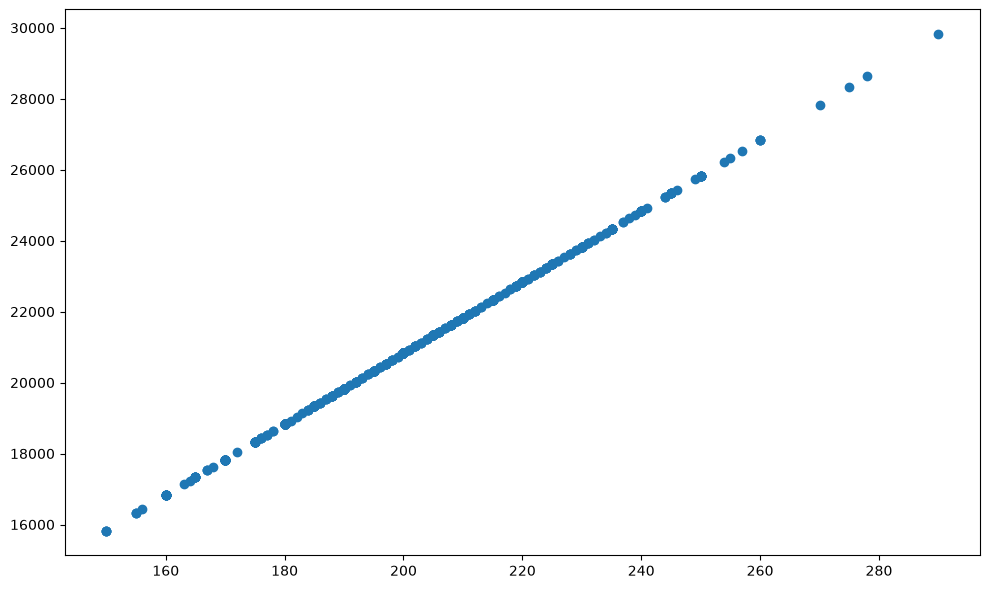

In [17]:
plt.figure(figsize=(10,6))
plt.scatter(heights, salaries)
plt.tight_layout()
plt.show()

In [22]:
salaries = 1000 + np.sin((heights - heights.min()) / (heights.max() - heights.mean())) * 100
print(f"Covariance matrix: {np.cov(heights, salaries)}")
print(f"Covariance: {np.cov(heights, salaries)[0,1]}")
print(f"Correlation matrix: {np.corrcoef(heights, salaries)}")
print(f"Correlation: {np.corrcoef(heights, salaries)[0,1]}")

Covariance matrix: [[441.63557066 393.30429863]
 [393.30429863 356.60592634]]
Covariance: 393.3042986302803
Correlation matrix: [[1.         0.99106558]
 [0.99106558 1.        ]]
Correlation: 0.9910655775558532


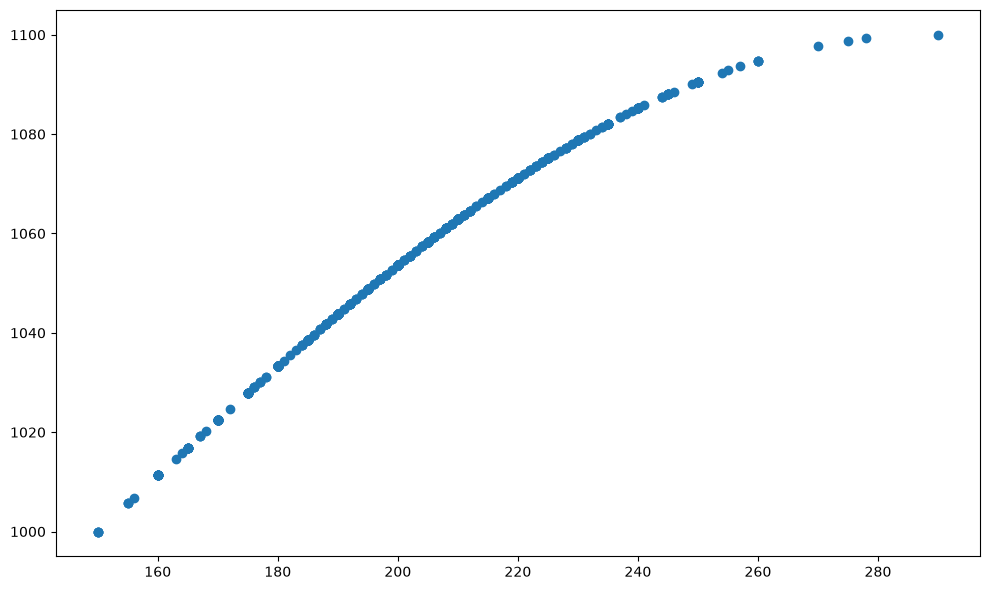

In [23]:
plt.figure(figsize=(10,6))
plt.scatter(heights, salaries)
plt.tight_layout()
plt.show()

In [24]:
salaries = 1000 + np.sin((heights - heights.min()) / (heights.max() - heights.mean())) * 100 + np.random.random(size=len(heights))*20+10
print(f"Covariance matrix: {np.cov(heights, salaries)}")
print(f"Covariance: {np.cov(heights, salaries)[0,1]}")
print(f"Correlation matrix: {np.corrcoef(heights, salaries)}")
print(f"Correlation: {np.corrcoef(heights, salaries)[0,1]}")

Covariance matrix: [[441.63557066 395.12048723]
 [395.12048723 393.30365536]]
Covariance: 395.1204872308443
Correlation matrix: [[1.       0.948055]
 [0.948055 1.      ]]
Correlation: 0.9480550033616706


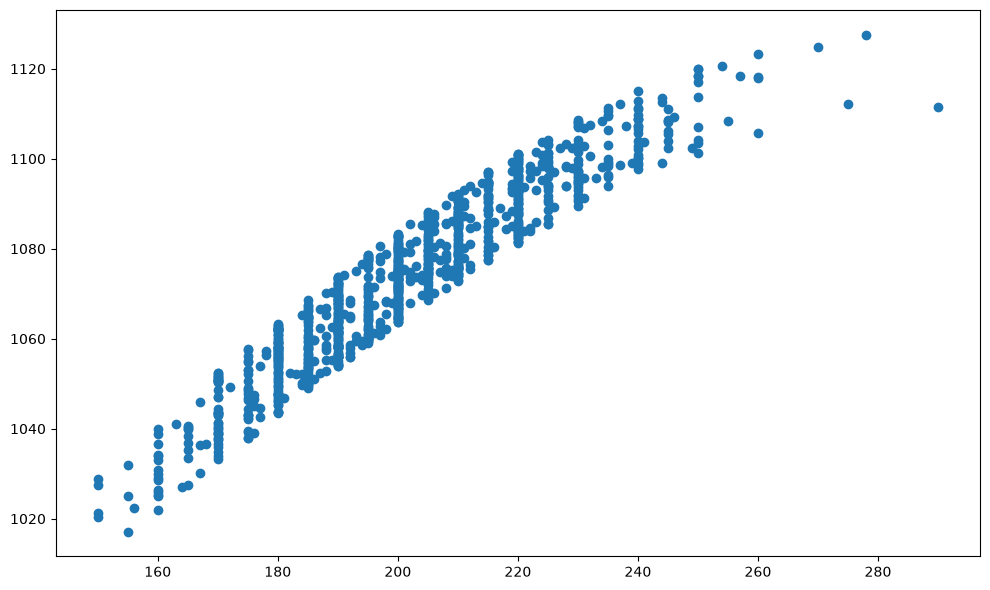

In [25]:
plt.figure(figsize=(10,6))
plt.scatter(heights, salaries)
plt.tight_layout()
plt.show()

<!-- Can you guess why the dots line up into vertical lines like this? -->

> Q. Can you guess why the dots line up into vertical lines like this?

### A. Because of the added randomness to each salary (+ np.random.random(size=len(heights))*20+10)

In [34]:
np.corrcoef(heights, df['Weight'])

array([[1.        , 0.52959196],
       [0.52959196, 1.        ]])

In [39]:
np.corrcoef(df['Height'].ffill(), df['Weight'])

array([[1.        , 0.52959196],
       [0.52959196, 1.        ]])

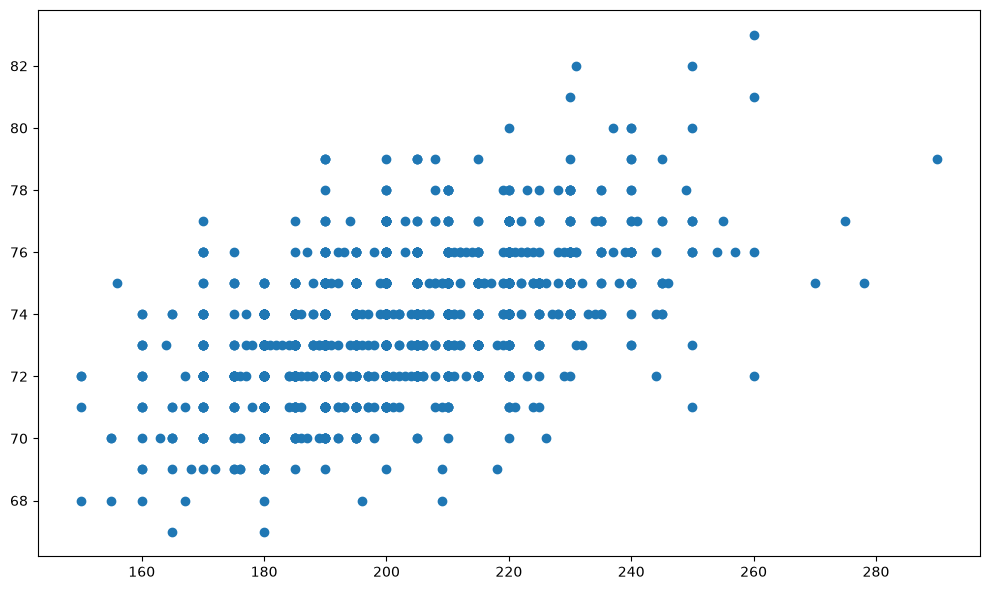

In [41]:
plt.figure(figsize=(10,6))
plt.scatter(df['Height'], df['Weight'])
plt.tight_layout()
plt.show()